# LangGraph Subgraphs — Different State Schemas

This notebook demonstrates the **different-schema** pattern for LangGraph
subgraphs: the subgraph (`SubState`) has its own state shape, separate from
the parent graph's (`ParentState`). Because the schemas differ, the parent
graph can't add the compiled subgraph directly as a node — instead a small
wrapper node (`translate_answer`) calls `subgraph.invoke(...)`, translating
between the two state shapes by hand.

Flow: `question` → generate an English answer (parent) → invoke the subgraph
to translate it to Hindi (subgraph has its own `input_text`/`translated_text`
state).

**Models (local, via [Ollama](https://ollama.com), no API key required):**
- `llama3.2:3b` — small, fast local model used to generate the initial English answer.
- `gpt-oss:120b-cloud` — larger model (run through Ollama's cloud inference) used for the Hindi translation, where quality matters more.

**Prerequisites:**
1. [Ollama](https://ollama.com) installed and running.
2. Models pulled/available: `ollama pull llama3.2:3b` and `ollama pull gpt-oss:120b-cloud` (the `-cloud` model needs `ollama signin` once, since it runs on Ollama's cloud rather than your machine).
3. Run this notebook using the project's `.venv` kernel (it already has `langchain-ollama`, `langgraph`, etc. installed).

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama

In [ ]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

**Subgraph's own state** — deliberately different from `ParentState` (below):
it only knows about `input_text` / `translated_text`, not `question` or
`answer_eng`.

In [3]:
subgraph_llm = ChatOllama(model='gpt-oss:120b-cloud')

The subgraph uses the bigger `gpt-oss:120b-cloud` model, since translation
quality benefits from a larger model.

In [4]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

**Subgraph node** — translates `input_text` into `translated_text`.

In [5]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

**Build & compile the subgraph** on its own `SubState` — a single
`translate_text` node from `START` to `END`.

In [6]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

**Parent state** — separate schema from the subgraph's `SubState`, which is
exactly why the parent graph will need a wrapper node to bridge between them.

In [7]:
parent_llm = ChatOllama(model='llama3.2:3b')

The parent graph uses the small, fast `llama3.2:3b` model to draft the
English answer.

In [8]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

**Parent node** — generates the English answer for the incoming `question`.

In [9]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

**Wrapper node** — this is the bridge between the two schemas: it builds the
subgraph's `SubState` input from `ParentState`, invokes the subgraph, then
maps the subgraph's output back into `ParentState`.

In [10]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

**Build the parent graph.** Unlike the shared-schema notebook, `translate` here
is the plain Python wrapper function (`translate_answer`), not the compiled
subgraph itself.

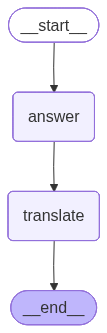

In [11]:
graph = parent_builder.compile()

graph

Compile the parent graph and (in a notebook with Mermaid/graphviz support)
render it.

In [12]:
graph.invoke({'question': 'What is Agentic AI in simple terms?'})

{'question': 'What is Agentic AI in simple terms?',
 'answer_eng': 'In simple terms, Agentic AI refers to Artificial Intelligence that can make decisions and act on its own without being explicitly programmed by humans.\n\nThink of it like a robot that can set its own goals, plan its actions, and adapt to changing situations, all without needing human intervention. It\'s designed to be autonomous, self-directed, and proactive – like a truly "agentic" (meaning having or showing initiative) entity!',
 'answer_hin': 'सरल शब्दों में, एजेंटिक एआई का मतलब ऐसी कृत्रिम बुद्धिमत्ता से है जो बिना मनुष्यों द्वारा स्पष्ट रूप से प्रोग्राम किए अपने निर्णय ले सकती है और स्वयं कार्य कर सकती है।\n\nइसे ऐसे समझें जैसे एक रोबोट जो अपने लक्ष्य खुद स्थापित कर सकता है, अपनी कार्रवाइयों की योजना बना सकता है, और बदलती परिस्थितियों के अनुसार अनुकूल हो सकता है, बिना मानव हस्तक्षेप के। इसे स्वायत्त, स्व‑निर्देशित और सक्रिय होने के लिए डिजाइन किया गया है – जैसे एक वास्तविक “एजेंटिक” (अर्थात पहल करने वाला) इकाई!'}

Run the whole graph end-to-end: ask a question in English, get back both the
English answer and its Hindi translation.